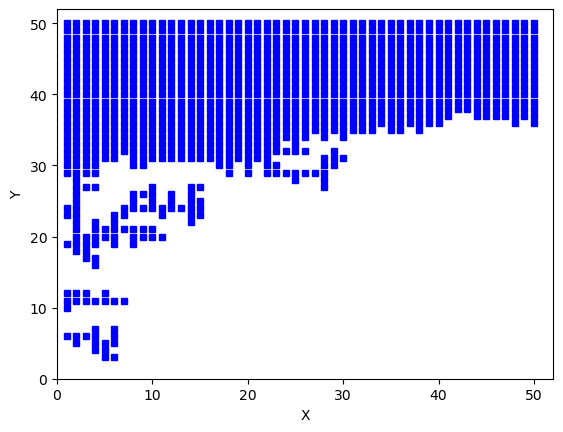

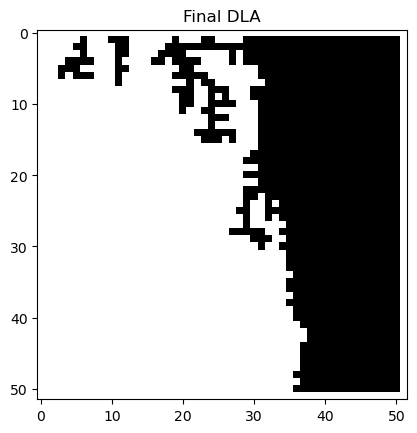

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

h, w = 50, 50
lattice = np.zeros((h + 2, w + 2)) 

num_points = np.random.randint(2, 4)
upper_positions = np.random.choice(w, num_points, replace=False) + 1
for pos in upper_positions:
    lattice[1, pos] = 1

fig, ax = plt.subplots()
xi, yi = np.where(lattice)
hl, = ax.plot(xi, yi, linestyle="none", markersize=5, marker="s", color='blue')
ax.set_xlim(0, w + 2)
ax.set_ylim(0, h + 2)
ax.set_xlabel('X')
ax.set_ylabel('Y')

def update(frame):
    global lattice, xi, yi
    
    x = np.random.randint(1, w + 1)
    y = h + 1

    max_iterations = 10000 
    for _ in range(max_iterations):
        direction = np.random.randint(0, 8)
        dx, dy = {
            0: (1, 0), 1: (-1, 0), 2: (0, 1), 3: (0, -1),
            4: (1, 1), 5: (-1, -1), 6: (1, -1), 7: (-1, 1)
        }[direction]

        x_new = x + dx
        y_new = y + dy

        x_new = max(1, min(x_new, w))
        y_new = max(1, min(y_new, h))

        neighbors = [
            lattice[x_new - 1, y_new], lattice[x_new + 1, y_new],
            lattice[x_new, y_new - 1], lattice[x_new, y_new + 1]
        ]
        if lattice[x_new, y_new] == 0 and sum(neighbors) >= 1:
            lattice[x_new, y_new] = 1
            xi, yi = np.where(lattice)
            hl.set_xdata(xi)
            hl.set_ydata(yi)
            return hl,

        x, y = x_new, y_new

    return hl,

ani = FuncAnimation(fig, update, frames=1000, repeat=False, blit=True)

HTML(ani.to_jshtml())

plt.figure()
plt.imshow(lattice, cmap='binary', interpolation = 'none')
plt.title('Final DLA')
plt.show()